In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


df=pd.read_excel(r"C:\Users\User\Desktop\단조실\2.이중열교환기\HeatExchanger_frame.xlsx")


df.loc[df['type']=='P','dt1']=df["T1"]-df["t1"]
df.loc[df['type']=='P',"dt2"]=df["T2"]-df["t2"]
df.loc[df['type']=='C','dt1']=df['T1']-df['t2']
df.loc[df['type']=='C','dt2']=df['T2']-df['t1']

def logmean(x,y):
    return (x-y)/(np.log(x/y))


df["dtm"]=logmean(df['dt1'],df['dt2'])

df.to_excel(r"C:\Users\User\Desktop\단조실\2.이중열교환기\HeatExchanger_result.xlsx")

print('s')


s


In [17]:
from CoolProp.CoolProp import PropsSI

T_mean=(0.5*(df['T1']+df['T2']))+273
t_mean=(0.5*(df['t2']+df['t1']))+273

print(T_mean)

df['Qh']=df['W']*df['c']*(df['T2']-df['T1'])

df.loc[df['type']=='P','Qc']=df['w']*df['c']*(df['t2']-df['t1'])
df.loc[df['type']=='C','Qc']=df['w']*df['c']*(df['t1']-df['t2'])

df['VIS']=T_mean.apply(lambda T:PropsSI("V","T", T,"P",101325,"Water"))
df['vis']=t_mean.apply(lambda T:PropsSI("V","T", T,"P",101325,"Water"))

print(df['VIS'])

df['RE']=(4*df['W'])/(np.pi*df['Ri']*2*df['VIS']) #

df['rr']=(df['ri']-df['R'])/2 #수력학적 반지름

df['Re']=(4*df['w'])/(np.pi*df['rr']*2*df['vis']) 

df.to_excel(r"C:\Users\User\Desktop\단조실\2.이중열교환기\HeatExchanger_result.xlsx")

print("complte")


0    325.0
1    323.5
2    308.0
3    299.0
dtype: float64
0    0.000530
1    0.000543
2    0.000721
3    0.000873
Name: VIS, dtype: float64
complte


In [18]:
df['R_bar']=logmean(df['Ri'],df['R'])
df['A1']=np.pi*df['R_bar']**2

df['A2']=np.pi*logmean(df['R'],df['ri'])**2

df['r_bar']=logmean(df['ri'],df['r'])
df['A3']=np.pi*df['r_bar']**2

df.to_excel(r"C:\Users\User\Desktop\단조실\2.이중열교환기\HeatExchanger_result.xlsx")
print('complete')

complete


In [19]:
summation=(1/(df['A1']*df['h1']))+(df['L']/(df['A2']*df['k']))+(1/(df['A3']*df['h2']))

df['U1']=summation/df['A1']
df['U2']=summation/df['A2']


df['eta']=-df['Qc']/df['Qh']

df.to_excel(r"C:\Users\User\Desktop\단조실\2.이중열교환기\HeatExchanger_result.xlsx")
print('complete')

complete


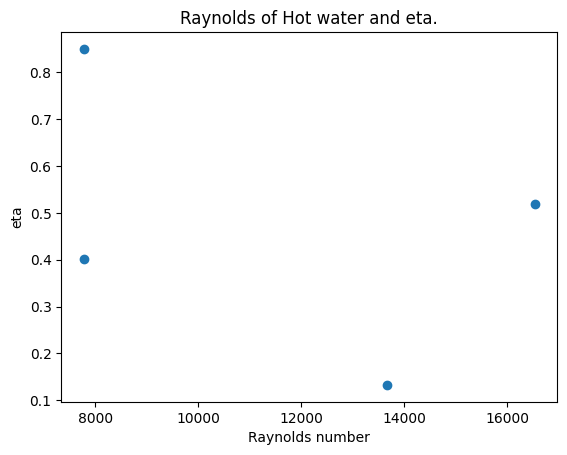

Text(0.5, 0, 'Raynolds number')

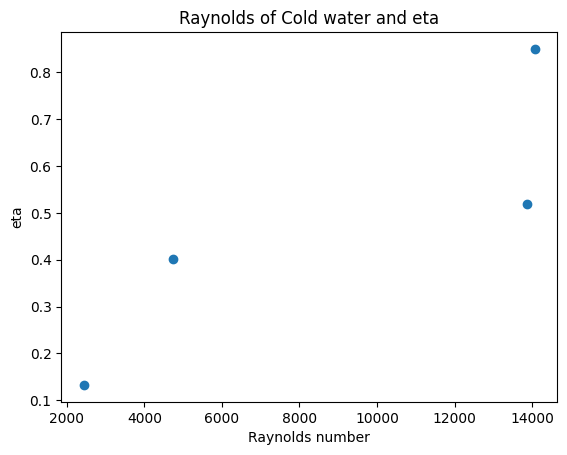

In [26]:
plt.scatter(df['RE'],df['eta'])
plt.title('Raynolds of Hot water and eta.')
plt.ylabel('eta')
plt.xlabel('Raynolds number')
plt.show()
plt.close()

plt.scatter(df['Re'],df['eta'])
plt.title('Raynolds of Cold water and eta')
plt.ylabel('eta')
plt.xlabel('Raynolds number')
#plt.close()

